In [1]:
import numpy as np
import pandas as pd
from src.metrics import evaluate_regression
from src.models.linear import build_linear_models
import time

In [2]:
data = pd.read_csv("//dataset/staging/data_sau_clean.csv")

print("Shape:", data.shape)

Shape: (117322, 13)


In [4]:
from src.feature_engineering.build_feature import build_features

features = build_features(
    data
)

X_train = features["X_train"]
X_test  = features["X_test"]
y_train = features["y_train"]
y_test  = features["y_test"]

In [6]:
# ===== Linear =====
results = {}
for name, model in build_linear_models().items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    y_pred = model.predict(X_test)
    results[name] = {
        **evaluate_regression(y_test, y_pred),
        "train_time": train_time}


In [8]:
for model, metrics in results.items():
    print(f"\n{model}")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")


Linear
  MAE: 0.3568
  RMSE: 0.5538
  R2: 0.6921
  train_time: 9.2673

Ridge
  MAE: 0.3565
  RMSE: 0.5527
  R2: 0.6933
  train_time: 1.1537

Lasso
  MAE: 0.3842
  RMSE: 0.5877
  R2: 0.6532
  train_time: 4.9273


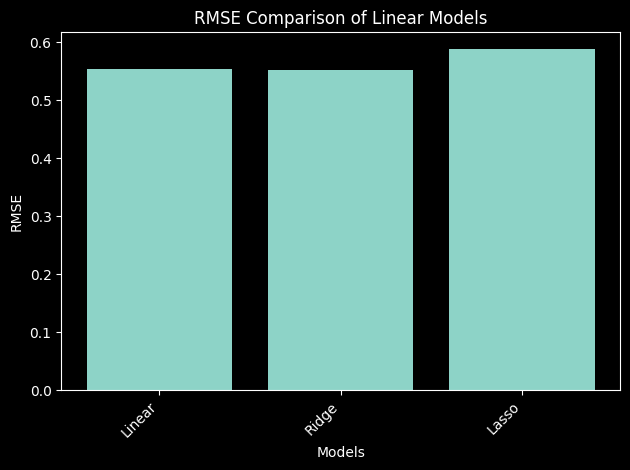

In [9]:
import matplotlib.pyplot as plt

model_names = list(results.keys())
rmse_values = [results[name]["RMSE"] for name in model_names]

plt.figure()
plt.bar(model_names, rmse_values)
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Linear Models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


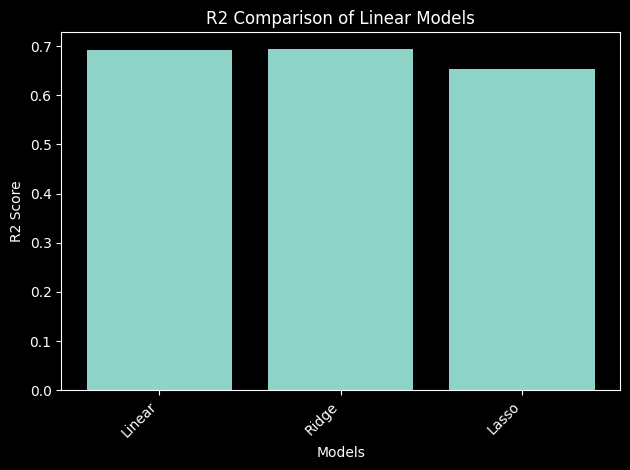

In [10]:
r2_values = [results[name]["R2"] for name in model_names]

plt.figure()
plt.bar(model_names, r2_values)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("R2 Comparison of Linear Models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


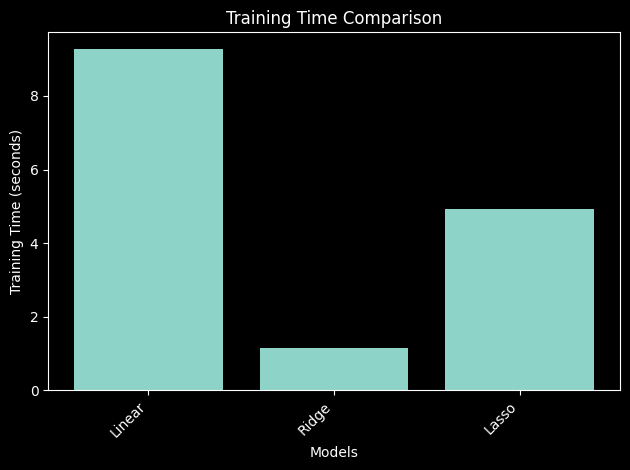

In [11]:
train_times = [results[name]["train_time"] for name in model_names]

plt.figure()
plt.bar(model_names, train_times)
plt.xlabel("Models")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


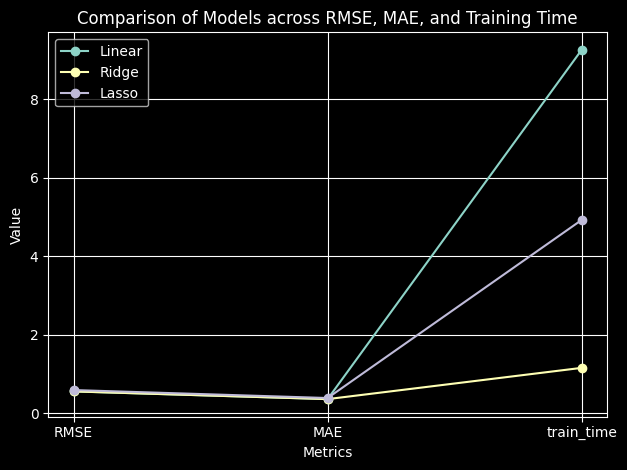

In [12]:
import matplotlib.pyplot as plt

metrics = ["RMSE", "MAE", "train_time"]
models = list(results.keys())

plt.figure()

for model in models:
    values = [results[model][m] for m in metrics]
    plt.plot(metrics, values, marker='o', label=model)

plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("Comparison of Models across RMSE, MAE, and Training Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
